In [1]:
!pip install corus
!python3 -m spacy download ru_core_news_sm
!pip install gensim
!pip install razdel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.7/83.7 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 60.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 68.3 MB/s eta 0:00:00


In [2]:
!wget https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz

--2026-03-12 15:55:42--  https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/87156914/0b363e00-0126-11e9-9e3c-e8c235463bd6?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-12T16%3A33%3A47Z&rscd=attachment%3B+filename%3Dlenta-ru-news.csv.gz&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-12T15%3A33%3A22Z&ske=2026-03-12T16%3A33%3A47Z&sks=b&skv=2018-11-09&sig=y7Jppark8gJOTuJsQvtE1LvfJRiBH2Eex9wQ1s%2BSTY8%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc3MzMzNDU0MywibmJmIjoxNzczMzMwOTQzLCJwYXRoIjoicmVsZWFzZWFzc2V0

In [23]:
import gensim.models
from corus import load_lenta
import spacy
import string
from tqdm import tqdm
import string
import pandas as pd
from razdel import tokenize, sentenize
import pymorphy3
import numpy as np
import re
import random

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
    )
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import RandomizedSearchCV

from functools import lru_cache
from sklearn.base import clone

from tempfile import mkdtemp
from joblib import Memory

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
RANDOM_STATE = 42

In [5]:
from typing_extensions import dataclass_transform
path = 'lenta-ru-news.csv.gz'
records = load_lenta(path)
data_sup = []

for i, record in enumerate(tqdm(records, total=100000)):
    if i >= 100000:
        break
    data_sup.append({
        'text': record.text,
        'title': record.title,
        'topic': record.topic
    })

data = pd.DataFrame(data_sup)

print(data.info())
data.head()

100%|██████████| 100000/100000 [00:06<00:00, 15121.65it/s]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    100000 non-null  object
 1   title   100000 non-null  object
 2   topic   100000 non-null  object
dtypes: object(3)
memory usage: 2.3+ MB
None


,text,title,topic
0,Вице-премьер по социальным вопросам Татьяна Го...,Названы регионы России с самой высокой смертно...,Россия
1,Австрийские правоохранительные органы не предс...,Австрия не представила доказательств вины росс...,Спорт
2,Сотрудники социальной сети Instagram проанализ...,Обнаружено самое счастливое место на планете,Путешествия
3,С начала расследования российского вмешательст...,В США раскрыли сумму расходов на расследование...,Мир
4,Хакерская группировка Anonymous опубликовала н...,Хакеры рассказали о планах Великобритании зами...,Мир


In [ ]:
data['topic'].value_counts()

,count
topic,
Россия,15151
Мир,14421
Спорт,10045
Экономика,7682
Интернет и СМИ,6935
Силовые структуры,6925
Бывший СССР,6810
Культура,6578
Наука и техника,5645


Можно увидеть, что наш датасет содержит 19 различных классов, причем неоджиданных опечаток и.т.д в таргетной фиче нет, поэтому предобработка и чистка именно таргетной переменной не требуется

In [ ]:
data["text_norm_simple"] = (
    data["text"].str.lower()
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)

In [ ]:
data.duplicated("text_norm_simple").sum()

np.int64(3)

Во всем стотысячном корпусе найдено всего полных 3 дубликата, можно считать, что представленный датасет не содержит дублей

Предлагаю посмотреть на сэмплы с отсутсвием топика и топиков "оружие" и в дальнейшем удалить их, так как данные классы имеют калоссально низкое количество представителей. В данной ситуации не предоставлется возможным обучить модель детектировать эти классы

In [ ]:
data[(data['topic'] == 'Оружие') | (data['topic'] == '')]

,text,title,topic,text_norm_simple
3530,В учебном центре врачебной практики Praxi Medi...,Японский профессор рассказал о свойствах молек...,,в учебном центре врачебной практики praxi medi...
8736,Организаторы выставки «ИгроМир» и фестиваля Co...,Подведены итоги «ИгроМира» и Comic Con Russia,,организаторы выставки «игромир» и фестиваля co...
9956,Российская студия разработчиков Enplex Games р...,Московские разработчики показали Population Zero,,российская студия разработчиков enplex games р...
10308,Современный рынок товаров и услуг настолько ра...,Подведены итоги IX ежегодной премии «Права пот...,,современный рынок товаров и услуг настолько ра...
16333,Оргкомитет Восточного экономического форума на...,Опубликована деловая программа Восточного экон...,,оргкомитет восточного экономического форума на...
17562,Фонд Росконгресс и Федерация торгово-промышлен...,Росконгресс и Федерация ТПП Мьянмы договорилис...,,фонд росконгресс и федерация торгово-промышлен...
22497,США предъявили КНДР требования по 47 пунктам в...,США предъявили КНДР 47 требований,,сша предъявили кндр требования по 47 пунктам в...
24522,В Красноярском крае задержали подозреваемого в...,Сибиряк вступился за брата и зарубил четверых ...,,в красноярском крае задержали подозреваемого в...
29517,В Москве состоялась встреча советника президен...,Глобальный саммит производства и индустриализа...,,в москве состоялась встреча советника президен...
47811,Портал «Индикaтop» в прямом эфире покажет семи...,Беглый президент Киргизии выступит с изобретат...,,портал «индикaтop» в прямом эфире покажет семи...


In [11]:
index_to_drop = data[(data['topic'] == 'Оружие') | (data['topic'] == '')].index
data = data.drop(index_to_drop)

In [ ]:
data["len_text"] = data["text"].str.split().str.len()
data["len_title"] = data["title"].str.split().str.len()

<Axes: >

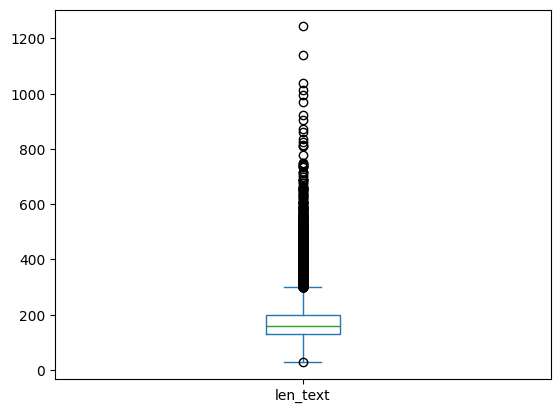

In [ ]:
data['len_text'].plot.box()

<Axes: >

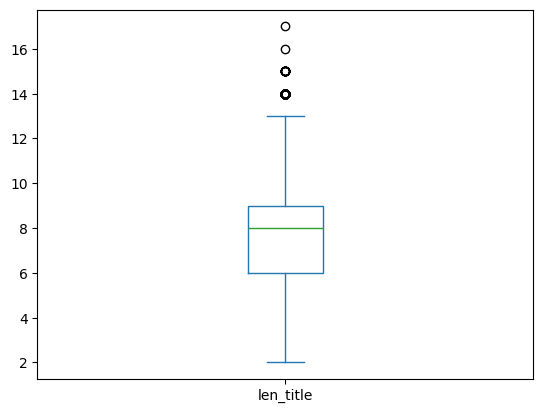

In [ ]:
data['len_title'].plot.box()

Создадим функцию для предобработки текста, будем приводить весь текст к нижнему ригистру, далее токенизировать через razdel и затем буквенные токены дополнительно лемматизировать через pymorphy, так как для русского языка лемматизация работает сильно лучше по сравнению со стемингом. Также включим кэширование с максиммальным количеством токенов равным в целом размеру датасета

In [8]:
morph = pymorphy3.MorphAnalyzer()

@lru_cache(maxsize=100000)
def lemmatize_razdel(s: str) -> str:
    tokens = [t.text for t in tokenize(s)]
    lemmas = []
    for t in tokens:
        if re.fullmatch(r"[a-zа-яё]+", t):
            lemmas.append(morph.parse(t)[0].normal_form)
        else:
            lemmas.append(t)
    return " ".join(lemmas)

@lru_cache(maxsize=100000)
def normalize_text(s: str) -> str:
    return s.lower()

@lru_cache(maxsize=100000)
def preprocessor(s: str) -> str:
    s = normalize_text(s)
    s = lemmatize_razdel(s)
    return s

Соберем призноковое описание и таргет. Для усиления влияния заголовка статьи на общее представления сэмпла в признаковом пространстве будем включать зоголовок в текст дважды. После разделим выборку со стратификацией по таргету, чтобы учесть дисбаланс классов

In [12]:
X = (data["text"] + " " + data["title"] + " " + data["title"]).values
y = data["topic"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=RANDOM_STATE
)

In [ ]:
len(X_train)

59988

In [ ]:
y_train

array(['Мир', 'Спорт', 'Силовые структуры', ..., 'Спорт', 'Мир', 'Спорт'],
      dtype=object)

Создадим глупый бейзлайн, будем рандомно вытаскивать класс для каждого сэпла данных

In [10]:
dummy_pred = []
unique_labels = np.unique(y_train)

for _ in range(len(X_train[:10000])):
  dummy_pred.append(random.choice(unique_labels))

print("Classification Report:")
print(classification_report(y_train[:10000], dummy_pred, digits=4))

Classification Report:
                   precision    recall  f1-score   support

   69-я параллель     0.0110    0.0750    0.0192        80
           Бизнес     0.0227    0.0680    0.0341       206
      Бывший СССР     0.0528    0.0514    0.0521       642
              Дом     0.0299    0.0511    0.0377       333
         Из жизни     0.0626    0.0696    0.0659       503
   Интернет и СМИ     0.0914    0.0777    0.0840       695
             Крым     0.0084    0.0595    0.0147        84
    Культпросвет      0.0033    0.0645    0.0062        31
         Культура     0.0724    0.0699    0.0711       687
              Мир     0.1516    0.0652    0.0912      1441
  Наука и техника     0.0534    0.0461    0.0495       608
      Путешествия     0.0248    0.0449    0.0320       312
           Россия     0.1453    0.0553    0.0801      1554
Силовые структуры     0.0491    0.0443    0.0466       677
            Спорт     0.1233    0.0710    0.0901      1000
         Ценности     0.0389    

Соберем пайлпайны с bow и tfidf векторизаторами после для классификации будем использовать лог рег с флагом баланса классов, чтобы учитывать в весах модели частоту встречаемости конкретного класса пропорционально.

In [10]:
tfidf_vectorizer = TfidfVectorizer(
    preprocessor=preprocessor,
    token_pattern=r"(?u)\b[\wёЁ]+\b",
    ngram_range=(1, 2),
    min_df=3,
    max_features=100_000,
    sublinear_tf=True,
    dtype=np.float32
)

bow_vectorizer = CountVectorizer(
    preprocessor=preprocessor,
    token_pattern=r"(?u)\b[\wёЁ]+\b",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.7,
    dtype=np.float32
)

base_clf = LogisticRegression(
    solver="saga",
    max_iter=2000,
    n_jobs=-1,
    class_weight="balanced",
    C=2.0
)


cachedir = mkdtemp()
tfidf_pipe = Pipeline([
    ("tfidf", tfidf_vectorizer),
    ("clf", base_clf),
], memory=cachedir)

bow_pipe = Pipeline([
    ("bow", bow_vectorizer),
    ("clf", base_clf),
], memory=cachedir)

In [17]:
def eval_model(pipe, X, y):
  y_pred = pipe.predict(X)

  print("Classification Report:")
  print(classification_report(y, y_pred, digits=4))

Так как обучение пайплайна на cpu идет крайне долго, то для первых итераций предлагается взять только часть данных для обучения и валидации

In [16]:
bow_pipe.fit(X_train[:10000], y_train[:10000])
eval_model(bow_pipe, X_val[:2000], y_val[:2000])

Classification Report:
                   precision    recall  f1-score   support

   69-я параллель     0.9231    0.8571    0.8889        14
           Бизнес     0.6571    0.4792    0.5542        48
      Бывший СССР     0.8254    0.8062    0.8157       129
              Дом     0.7500    0.9000    0.8182        60
         Из жизни     0.7788    0.8073    0.7928       109
   Интернет и СМИ     0.8106    0.7431    0.7754       144
             Крым     0.7000    0.5385    0.6087        13
    Культпросвет      0.5000    0.5000    0.5000         2
         Культура     0.8947    0.8561    0.8750       139
              Мир     0.8388    0.9107    0.8733       280
  Наука и техника     0.8713    0.9167    0.8934        96
      Путешествия     0.8421    0.8533    0.8477        75
           Россия     0.7638    0.7893    0.7763       299
Силовые структуры     0.8209    0.7971    0.8088       138
            Спорт     0.9545    0.9403    0.9474       201
         Ценности     0.9398    

In [19]:
tfidf_pipe.fit(X_train[:10000], y_train[:10000])
eval_model(tfidf_pipe, X_val[:2000], y_val[:2000])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Classification Report:
                   precision    recall  f1-score   support

   69-я параллель     0.1842    1.0000    0.3111        14
           Бизнес     0.6667    0.6250    0.6452        48
      Бывший СССР     0.7917    0.8837    0.8352       129
              Дом     0.7833    0.7833    0.7833        60
         Из жизни     0.7544    0.7890    0.7713       109
   Интернет и СМИ     0.7883    0.7500    0.7687       144
             Крым     0.4667    0.5385    0.5000        13
    Культпросвет      0.0588    1.0000    0.1111         2
         Культура     0.8860    0.7266    0.7984       139
              Мир     0.8443    0.8714    0.8576       280
  Наука и техника     0.8350    0.8958    0.8643        96
      Путешествия     0.8356    0.8133    0.8243        75
           Россия     0.8647    0.5987    0.7075       299
Силовые структуры     0.7484    0.8623    0.8013       138
            Спорт     0.9394    0.9254    0.9323       201
         Ценности     0.9268    

Попробуем втрое увеличить размер выборки и посмотрим повлияет ли это на качыество модели. В данной задаче мультиклассовой классификации предлагается смореть на усредненные характеристики f1-score по всем классом

In [20]:
bow_pipe.fit(X_train[:30000], y_train[:30000])
eval_model(bow_pipe, X_val[:2000], y_val[:2000])

Classification Report:
                   precision    recall  f1-score   support

   69-я параллель     0.9231    0.8571    0.8889        14
           Бизнес     0.7250    0.6042    0.6591        48
      Бывший СССР     0.8444    0.8837    0.8636       129
              Дом     0.7606    0.9000    0.8244        60
         Из жизни     0.8056    0.7982    0.8018       109
   Интернет и СМИ     0.8582    0.7986    0.8273       144
             Крым     0.7778    0.5385    0.6364        13
    Культпросвет      0.2000    0.5000    0.2857         2
         Культура     0.9118    0.8921    0.9018       139
              Мир     0.8485    0.9000    0.8735       280
  Наука и техника     0.8654    0.9375    0.9000        96
      Путешествия     0.9265    0.8400    0.8811        75
           Россия     0.8456    0.8428    0.8442       299
Силовые структуры     0.8519    0.8333    0.8425       138
            Спорт     0.9646    0.9502    0.9574       201
         Ценности     0.9630    

In [21]:
tfidf_pipe.fit(X_train[:30000], y_train[:30000])
eval_model(tfidf_pipe, X_val[:2000], y_val[:2000])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Classification Report:
                   precision    recall  f1-score   support

   69-я параллель     0.7500    0.8571    0.8000        14
           Бизнес     0.6066    0.7708    0.6789        48
      Бывший СССР     0.8450    0.8450    0.8450       129
              Дом     0.7910    0.8833    0.8346        60
         Из жизни     0.7661    0.8716    0.8155       109
   Интернет и СМИ     0.8409    0.7708    0.8043       144
             Крым     0.3200    0.6154    0.4211        13
    Культпросвет      0.1429    1.0000    0.2500         2
         Культура     0.8889    0.8633    0.8759       139
              Мир     0.8681    0.8929    0.8803       280
  Наука и техника     0.8713    0.9167    0.8934        96
      Путешествия     0.8667    0.8667    0.8667        75
           Россия     0.8848    0.7191    0.7934       299
Силовые структуры     0.7834    0.8913    0.8339       138
            Спорт     0.9500    0.9453    0.9476       201
         Ценности     0.9506    

Также попробуем сместить тестовую выборку, чтобы оценить в целом обобщающую способность модели. Видно, что на другом наборе тестовых данных качество слегка падает.

In [22]:
eval_model(tfidf_pipe, X_val, y_val)

Classification Report:
                   precision    recall  f1-score   support

   69-я параллель     0.8759    0.7362    0.8000       163
           Бизнес     0.5744    0.6985    0.6304       398
      Бывший СССР     0.8679    0.8539    0.8608      1362
              Дом     0.8613    0.8739    0.8675       682
         Из жизни     0.7498    0.8552    0.7990       981
   Интернет и СМИ     0.8294    0.8061    0.8176      1387
             Крым     0.4817    0.7955    0.6000       132
    Культпросвет      0.2557    0.7377    0.3797        61
         Культура     0.8824    0.8670    0.8747      1316
              Мир     0.8588    0.8606    0.8597      2884
  Наука и техника     0.8795    0.9114    0.8952      1129
      Путешествия     0.7997    0.8605    0.8290       645
           Россия     0.8721    0.7178    0.7875      3030
Силовые структуры     0.7207    0.8383    0.7750      1385
            Спорт     0.9596    0.9691    0.9643      2009
         Ценности     0.9452    

Для улучшения качества модели и обобщения результатов на полный датасет предлагается потюнить гиперпараметры для пайплайна с tfidf векторизатором, так как идейно он должен содержать больше информации о тексте в своих векторах по сравнению с обычным bow

Перепишеи немнгого фукнции для препроцессинга, чтобы получить на выходе нампай массив. Это необходимо для дальнейшего реализации кэширования расчитанных векторов, которое требует список токенов в сэмлпе в качестве хэшируемого объекта

In [13]:
from functools import lru_cache


morph = pymorphy3.MorphAnalyzer()

def normalize_text(s):
    s = s.lower()
    return s

@lru_cache(maxsize=100_000)
def lemma_token_cached(token):
      return morph.parse(token)[0].normal_form

def preprocess_one_cached(s):
    s = normalize_text(s)
    tokens = [t.text for t in tokenize(s)]
    lemmas = [lemma_token_cached(t) for t in tokens]
    return " ".join(lemmas)

def preprocess_corpus(texts):
    out = [preprocess_one_cached(str(t)) for t in texts]
    return np.asarray(out, dtype=object)

Снизим число максимальных итераций лог рега, так как нам предстоит выполнять больше количество обучений пайплайна при переборе разных гиперпараметров

In [14]:
cache_dir = "/content/joblib_cache"
memory = Memory(cache_dir, verbose=0)

prep_step = FunctionTransformer(
    preprocess_corpus,
    validate=False,
    feature_names_out="one-to-one"
)

tfidf_vec = TfidfVectorizer(
    token_pattern=r"\b[\wёЁ]+\b",
    dtype=np.float32
)

clf = LogisticRegression(
    solver="saga",
    max_iter=500,
    n_jobs=-1,
    class_weight="balanced"
)

tfidf_lr_pipe_cached = Pipeline(
    steps=[
        ("prep", prep_step),
        ("vect", tfidf_vec),
        ("clf", clf),
    ],
    memory=memory
)

Выполним оптимизацию параметров на чатси тренировочной выборки. Также будем проверять качество и обогащать трейн выборку с помощью кросс валидации на 3 фолдах

In [31]:
%%time

param_dist = {
    "vect__ngram_range": [(1, 1), (1, 2)],
    "vect__min_df": [2, 3, 5],
    "vect__max_df": [0.5, 0.7],
    "vect__sublinear_tf": [True, False],
    "clf__C": np.logspace(-2, 1, 15),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rs = RandomizedSearchCV(
    estimator=tfidf_lr_pipe_cached,
    param_distributions=param_dist,
    n_iter=15,
    scoring="f1_macro",
    n_jobs=1,
    cv=cv,
    verbose=1,
    random_state=42,
)

rs.fit(X_train[:10000], y_train[:10000])

best_model = rs.best_estimator_
rs.best_score_, rs.best_params_

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which 

CPU times: user 56min 12s, sys: 9.67 s, total: 56min 22s
Wall time: 56min 21s


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


(np.float64(0.7676070054572898),
 {'vect__sublinear_tf': True,
  'vect__ngram_range': (1, 2),
  'vect__min_df': 3,
  'vect__max_df': 0.7,
  'clf__C': np.float64(10.0)})

Теперь воспроизведем модель с параметрами, дающими наилучшее качество на метрике f1_macro, теперь можем увеличить число максимальных итераций используемого солвера при обучении лог рега

In [15]:
prep_step = FunctionTransformer(
    preprocess_corpus,
    validate=False,
    feature_names_out="one-to-one"
)

tfidf_vec = TfidfVectorizer(
    token_pattern=r"(?u)\b[\wёЁ]+\b",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.7,
    max_features=100_000,
    sublinear_tf=True,
    dtype=np.float32
)

clf = LogisticRegression(
    solver="saga",
    max_iter=1000,
    n_jobs=-1,
    class_weight="balanced",
    C=10.0
)

tfidf_lr_pipe_cached_best = Pipeline(
    steps=[
        ("prep", prep_step),
        ("vect", tfidf_vec),
        ("clf", clf),
    ],
    memory=memory
)

Также предлагается итеративно обучать новый пайплайн на тех же подвыборках датасета расширяя выборку. Сохраним все условия эксперимента для корректного сравнения качества с предыдущими алгоритмами

In [26]:
tfidf_lr_pipe_cached_best.fit(X_train[:10000], y_train[:10000])
eval_model(tfidf_lr_pipe_cached_best, X_val[:2000], y_val[:2000])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Classification Report:
                   precision    recall  f1-score   support

   69-я параллель     0.9000    0.6429    0.7500        14
           Бизнес     0.6667    0.5417    0.5977        48
      Бывший СССР     0.8058    0.8682    0.8358       129
              Дом     0.8197    0.8333    0.8264        60
         Из жизни     0.8034    0.8624    0.8319       109
   Интернет и СМИ     0.8346    0.7708    0.8014       144
             Крым     0.7273    0.6154    0.6667        13
    Культпросвет      0.2000    1.0000    0.3333         2
         Культура     0.9154    0.8561    0.8848       139
              Мир     0.8487    0.9214    0.8836       280
  Наука и техника     0.8627    0.9167    0.8889        96
      Путешествия     0.8333    0.8000    0.8163        75
           Россия     0.8110    0.7893    0.8000       299
Силовые структуры     0.8116    0.8116    0.8116       138
            Спорт     0.9490    0.9254    0.9370       201
         Ценности     0.9383    

In [27]:
tfidf_lr_pipe_cached_best.fit(X_train[:30000], y_train[:30000])
eval_model(tfidf_lr_pipe_cached_best, X_val[:2000], y_val[:2000])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Classification Report:
                   precision    recall  f1-score   support

   69-я параллель     0.8000    0.8571    0.8276        14
           Бизнес     0.7442    0.6667    0.7033        48
      Бывший СССР     0.8467    0.8992    0.8722       129
              Дом     0.8060    0.9000    0.8504        60
         Из жизни     0.8214    0.8440    0.8326       109
   Интернет и СМИ     0.8682    0.7778    0.8205       144
             Крым     0.6154    0.6154    0.6154        13
    Культпросвет      0.1818    1.0000    0.3077         2
         Культура     0.8714    0.8777    0.8746       139
              Мир     0.8716    0.9214    0.8958       280
  Наука и техника     0.9020    0.9583    0.9293        96
      Путешествия     0.8630    0.8400    0.8514        75
           Россия     0.8607    0.8060    0.8325       299
Силовые структуры     0.8540    0.8478    0.8509       138
            Спорт     0.9652    0.9652    0.9652       201
         Ценности     0.9630    

Видно, что модель обученная на оптимизированных параметрах с применением кросс валидации дает прирост в качестве по сравнению с дефолтными вариантами. Также снизилось и время обучения пайплайна на cpu за счет кэширования результатов работы векторизатора. Теперь обучим модель на полном сете трейн данных и выполним предсказание на отдельной отложенной выборке

In [18]:
tfidf_lr_pipe_cached_best.fit(X_train, y_train)
eval_model(tfidf_lr_pipe_cached_best, X_val[:2000], y_val[:2000])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Classification Report:
                   precision    recall  f1-score   support

   69-я параллель     0.7500    0.8571    0.8000        14
           Бизнес     0.6923    0.7500    0.7200        48
      Бывший СССР     0.8759    0.9302    0.9023       129
              Дом     0.8485    0.9333    0.8889        60
         Из жизни     0.8034    0.8624    0.8319       109
   Интернет и СМИ     0.8955    0.8333    0.8633       144
             Крым     0.7778    0.5385    0.6364        13
    Культпросвет      0.1000    1.0000    0.1818         2
         Культура     0.9360    0.8417    0.8864       139
              Мир     0.8866    0.9214    0.9037       280
  Наука и техника     0.9109    0.9583    0.9340        96
      Путешествия     0.8904    0.8667    0.8784        75
           Россия     0.8881    0.8227    0.8542       299
Силовые структуры     0.8531    0.8841    0.8683       138
            Спорт     0.9700    0.9652    0.9676       201
         Ценности     0.9529    

In [19]:
eval_model(tfidf_lr_pipe_cached_best, X_test, y_test)

Classification Report:
                   precision    recall  f1-score   support

   69-я параллель     0.8645    0.8221    0.8428       163
           Бизнес     0.6814    0.6967    0.6890       399
      Бывший СССР     0.8665    0.9053    0.8855      1362
              Дом     0.8766    0.9062    0.8911       682
         Из жизни     0.8306    0.8400    0.8353       981
   Интернет и СМИ     0.8411    0.8472    0.8441      1387
             Крым     0.8258    0.8258    0.8258       132
    Культпросвет      0.2430    0.8525    0.3782        61
         Культура     0.8994    0.8488    0.8733      1316
              Мир     0.8812    0.8974    0.8892      2884
  Наука и техника     0.9150    0.9150    0.9150      1129
      Путешествия     0.8688    0.8620    0.8654       645
           Россия     0.8696    0.8099    0.8387      3030
Силовые структуры     0.7937    0.8137    0.8036      1385
            Спорт     0.9663    0.9701    0.9682      2009
         Ценности     0.9424    

In [21]:
pred = tfidf_lr_pipe_cached_best.predict(X_test)

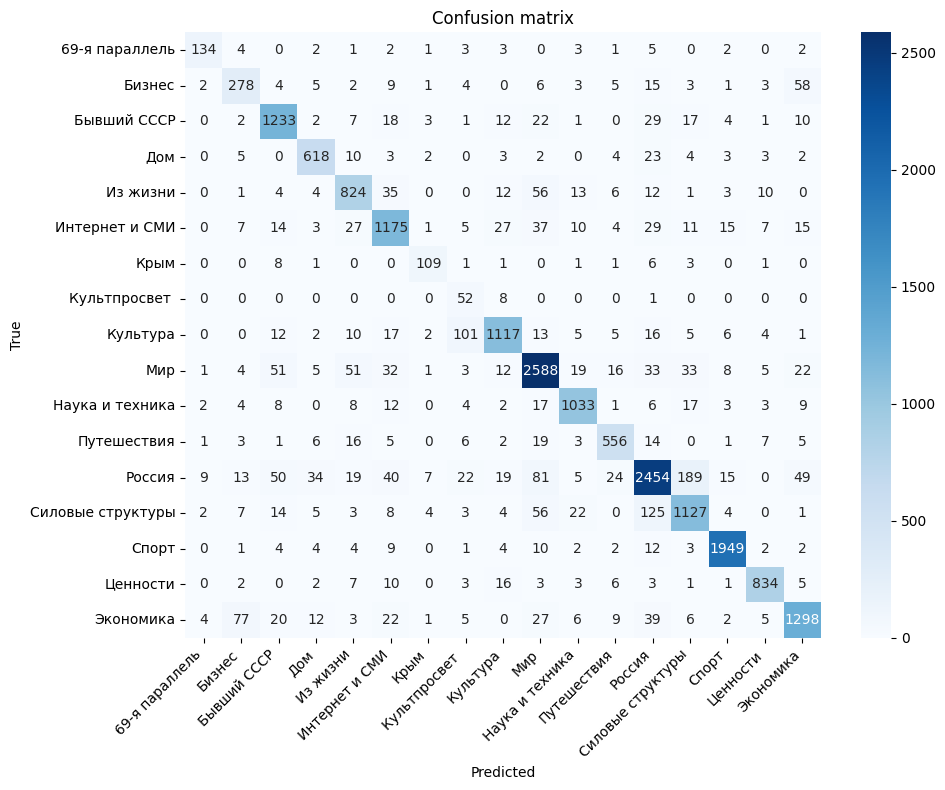

In [30]:
classes = tfidf_lr_pipe_cached_best.named_steps['clf'].classes_

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.title("Confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Из интерпретации предсказаний видно, что наибольшее количество ошибок модель допускает при классификации новостей с темой Россия и Мир, что и естественно так как именно таких примеров в количественном отношении больше, чем остальных сэмплов. Также можно найти некую неуверенность модели при классификации России и Силовых структур, наверное, так как новости о силовых структурах на русском о приоре зачастую связанны именно с отечественными силовыми структурами. Немного модель путается и с разделением Бизнеса и Экономика, опять таки понятия давольно схожи. Возможно для повышения качества нужно добавить примеров по категории бизнесс, так как их в трейне было совсем немного, это должно поправить ситуацию